# Toy pipeline: learning a DAG from data via $S^1$ ($N=3$)

This notebook demonstrates the **full learn-then-round pipeline** on a small
synthetic example with $N=3$ nodes.

**What we do:**
1. Generate data from a known causal DAG (ground truth).
2. Define a score function $s(G, \mathcal{D})$ that measures how well a DAG fits the data.
3. Evaluate $f(\vartheta) = s(\hat\theta(\vartheta), \mathcal{D})$ over the sphere $S^1$
   to see where the score is highest.
4. Run Riemannian gradient ascent on $S^1$ to find the optimal $\vartheta^*$.
5. Round $\vartheta^*$ via $\hat\theta$ and compare the recovered DAG to ground truth.

For $N=3$, the sphere $S^{N-2} = S^1$ is just a circle, so everything can be
plotted directly.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import networkx as nx

plt.rcParams.update({'font.size': 11, 'figure.dpi': 110})
np.random.seed(42)

FIGDIR = 'figures'
os.makedirs(FIGDIR, exist_ok=True)

# ── Rounding pipeline (same as dag_rounding.ipynb) ───────────────────────────

def closest_barycenter(p):
    p = np.asarray(p, dtype=float)
    N = len(p)
    j = np.argsort(p)[::-1]
    ps = p[j]
    D = ps[0] - (ps[1] if N > 1 else 0.0) - 0.5
    k = 1
    while D < 0 and k < N:
        k += 1
        nxt = ps[k] if k < N else 0.0
        D += k * (ps[k - 1] - nxt)
    return k, j[:k]

def normalize_to_simplex(x_desc):
    x = np.asarray(x_desc, dtype=float)
    x_min = x[-1]
    denom = -len(x) * x_min
    if denom < 1e-12:
        return np.ones(len(x)) / len(x)
    return (x - x_min) / denom

def rounding_map(x):
    x = np.asarray(x, dtype=float)
    N = len(x)
    sigma = np.argsort(x)[::-1]
    p = normalize_to_simplex(x[sigma])
    k, _ = closest_barycenter(p)
    top    = sigma[:k]
    bottom = sigma[k:]
    edges  = [(int(b), int(t)) for b in bottom for t in top]
    return dict(sigma=sigma, p=p, k=k, top=top, bottom=bottom, edges=edges)

# ── S¹ ⊂ H₀ = {x₀+x₁+x₂=0}: orthonormal basis ───────────────────────────────
u1 = np.array([ 1., -1.,  0.]) / np.sqrt(2)
u2 = np.array([ 1.,  1., -2.]) / np.sqrt(6)

def s1pt(theta):
    """Unit vector on S¹ ⊂ H₀ at angle theta."""
    return np.cos(theta) * u1 + np.sin(theta) * u2

print('Functions loaded.')

Functions loaded.


---
## Step 1 — Generate data from a known causal DAG

We use a **linear structural equation model** (SEM) on $N=3$ nodes:

$$
X_0 = \varepsilon_0, \quad
X_1 = \varepsilon_1, \quad
X_2 = 0.8\,X_0 + 0.6\,X_1 + 0.3\,\varepsilon_2,
$$

where $\varepsilon_i \sim \mathcal{N}(0,1)$ i.i.d.
The **true causal DAG** has edges $0 \to 2$ and $1 \to 2$
(nodes 0 and 1 are independent roots; node 2 is the effect).

The score we maximise is the **log-likelihood under Gaussian noise**:
for a bipartite DAG with top group $T$ and bottom group $B$,

$$
s(T, B, \mathcal{D})
= -\frac{n}{2}\sum_{j\in T} \log \widehat{\sigma}^2_j
  -\frac{n}{2}\sum_{i\in B} \log \operatorname{Var}(X_i),
$$

where $\widehat{\sigma}^2_j$ is the OLS residual variance when fitting $X_j$
on all nodes in $B$.

In [2]:
N, n = 3, 400

rng = np.random.RandomState(42)
X = np.zeros((n, N))
X[:, 0] = rng.randn(n)                                     # root
X[:, 1] = rng.randn(n)                                     # root
X[:, 2] = 0.8*X[:,0] + 0.6*X[:,1] + 0.3*rng.randn(n)    # effect

TRUE_TOP   = [2]
TRUE_BOT   = [0, 1]
TRUE_EDGES = [(0, 2), (1, 2)]

def score_dag(top, bottom, D):
    """
    Log-likelihood score for the bipartite DAG (bottom -> top).
    Nodes in 'top' each have all 'bottom' nodes as OLS parents.
    Nodes in 'bottom' are modelled as i.i.d. Gaussians (no parents).
    Higher score = better fit.
    """
    n_obs = D.shape[0]
    sc = 0.0
    for i in list(bottom):
        sc -= 0.5 * n_obs * np.log(max(np.var(D[:, i]), 1e-12))
    for j in list(top):
        if len(bottom) == 0:
            sc -= 0.5 * n_obs * np.log(max(np.var(D[:, j]), 1e-12))
        else:
            Xp = np.column_stack([D[:, list(bottom)], np.ones(n_obs)])
            w  = np.linalg.lstsq(Xp, D[:, j], rcond=None)[0]
            rss = np.var(D[:, j] - Xp @ w)
            sc -= 0.5 * n_obs * np.log(max(rss, 1e-12))
    return sc

true_sc = score_dag(TRUE_TOP, TRUE_BOT, X)
print(f'n = {n} samples,  N = {N} nodes')
print(f'True DAG: {{{TRUE_BOT[0]},{TRUE_BOT[1]}}} -> {{{TRUE_TOP[0]}}}')
print(f'Score of true DAG: {true_sc:.2f}')

n = 400 samples,  N = 3 nodes
True DAG: {0,1} -> {2}
Score of true DAG: 499.85


Saved: figures/toy_fig1_data.*


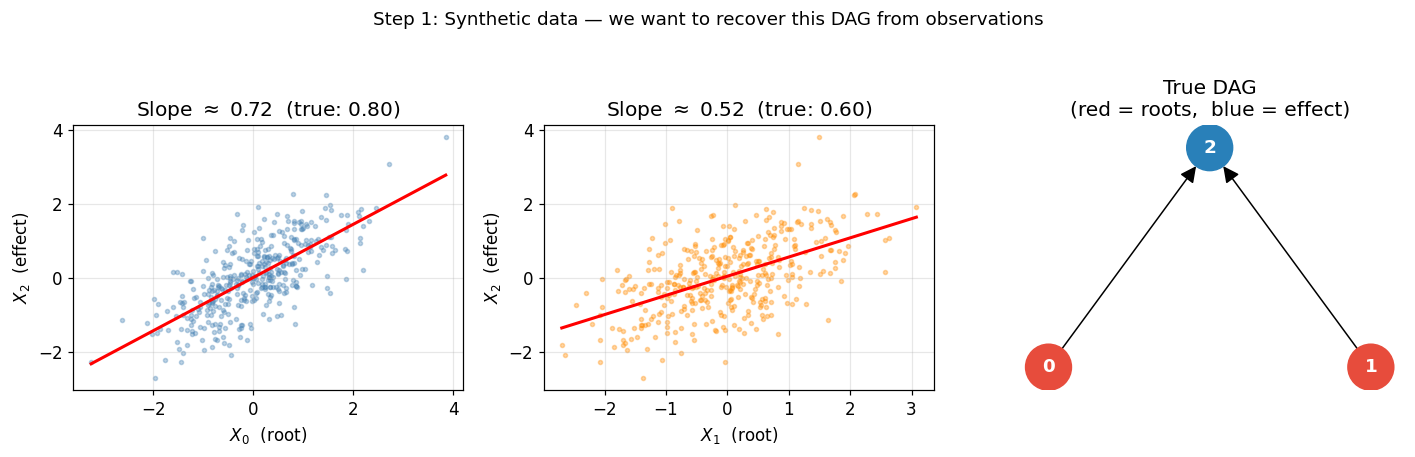

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Scatter X0 vs X2
axes[0].scatter(X[:,0], X[:,2], s=7, alpha=0.35, color='steelblue')
m0, b0 = np.polyfit(X[:,0], X[:,2], 1)
xs = np.linspace(X[:,0].min(), X[:,0].max(), 100)
axes[0].plot(xs, m0*xs+b0, 'r-', lw=2)
axes[0].set_xlabel('$X_0$  (root)'); axes[0].set_ylabel('$X_2$  (effect)')
axes[0].set_title(f'Slope $\\approx$ {m0:.2f}  (true: 0.80)')
axes[0].grid(True, alpha=0.3)

# Scatter X1 vs X2
axes[1].scatter(X[:,1], X[:,2], s=7, alpha=0.35, color='darkorange')
m1, b1 = np.polyfit(X[:,1], X[:,2], 1)
xs = np.linspace(X[:,1].min(), X[:,1].max(), 100)
axes[1].plot(xs, m1*xs+b1, 'r-', lw=2)
axes[1].set_xlabel('$X_1$  (root)'); axes[1].set_ylabel('$X_2$  (effect)')
axes[1].set_title(f'Slope $\\approx$ {m1:.2f}  (true: 0.60)')
axes[1].grid(True, alpha=0.3)

# True DAG
G_true = nx.DiGraph()
G_true.add_nodes_from(range(N))
G_true.add_edges_from(TRUE_EDGES)
pos = {0: (0.0, 0.0), 1: (2.0, 0.0), 2: (1.0, 1.5)}
node_col = ['#e74c3c', '#e74c3c', '#2980b9']   # red = root, blue = effect
nx.draw_networkx(G_true, pos=pos, ax=axes[2],
                 node_color=node_col, node_size=900,
                 font_color='white', font_weight='bold',
                 arrows=True, arrowsize=22)
axes[2].set_title('True DAG\n(red = roots,  blue = effect)')
axes[2].axis('off')

plt.suptitle('Step 1: Synthetic data — we want to recover this DAG from observations',
             fontsize=12, y=1.03)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/toy_fig1_data.pdf', bbox_inches='tight')
plt.savefig(f'{FIGDIR}/toy_fig1_data.png', bbox_inches='tight', dpi=150)
print(f'Saved: {FIGDIR}/toy_fig1_data.*')
plt.show()

---
## Step 2 — Score landscape on $S^1$

We sweep all angles $\theta\in[0,2\pi)$, compute
$\vartheta(\theta) = \cos\theta\cdot u_1 + \sin\theta\cdot u_2 \in S^1$,
apply the rounding map $\hat\theta(\vartheta)$ to get a DAG,
and evaluate its score on the data.

**Left panel**: which DAG (top group $T$) the rounding map returns at each angle.
The six coloured arcs are the six chambers of the braid arrangement (= six complete DAGs).

**Right panel**: the score $f(\vartheta) = s(\hat\theta(\vartheta),\mathcal{D})$
shown as a heatmap on the circle.  The maximum (marked $\star$) is in the
region where the true DAG $\{0,1\}\to\{2\}$ is recovered.

In [4]:
# Evaluate rounding and score at 3600 equally-spaced angles
angles = np.linspace(0, 2*np.pi, 3600, endpoint=False)
vartheta_pts = np.stack([s1pt(th) for th in angles])          # (3600, 3)
round_res    = [rounding_map(v) for v in vartheta_pts]
scores_all   = np.array([score_dag(r['top'], r['bottom'], X) for r in round_res])
top_labels   = [tuple(sorted(r['top'])) for r in round_res]

# Normalise to [0,1] for colour map
s_min, s_max = scores_all.min(), scores_all.max()
scores_norm  = (scores_all - s_min) / (s_max - s_min + 1e-12)

# What fraction of S¹ returns the true DAG?
true_mask = np.array([t == (2,) for t in top_labels])
print(f'True DAG region (T={{2}}) covers {true_mask.mean()*100:.1f}% of S¹')
print(f'Score range: [{s_min:.1f}, {s_max:.1f}]')
print(f'Best angle: {angles[scores_all.argmax()]:.3f} rad  '
      f'(top = {set(round_res[scores_all.argmax()]["top"])}, '
      f'bottom = {set(round_res[scores_all.argmax()]["bottom"])})')

True DAG region (T={2}) covers 10.6% of S¹
Score range: [102.0, 499.9]
Best angle: 4.379 rad  (top = {np.int64(2)}, bottom = {np.int64(0), np.int64(1)})


Saved: figures/toy_fig2_landscape.*


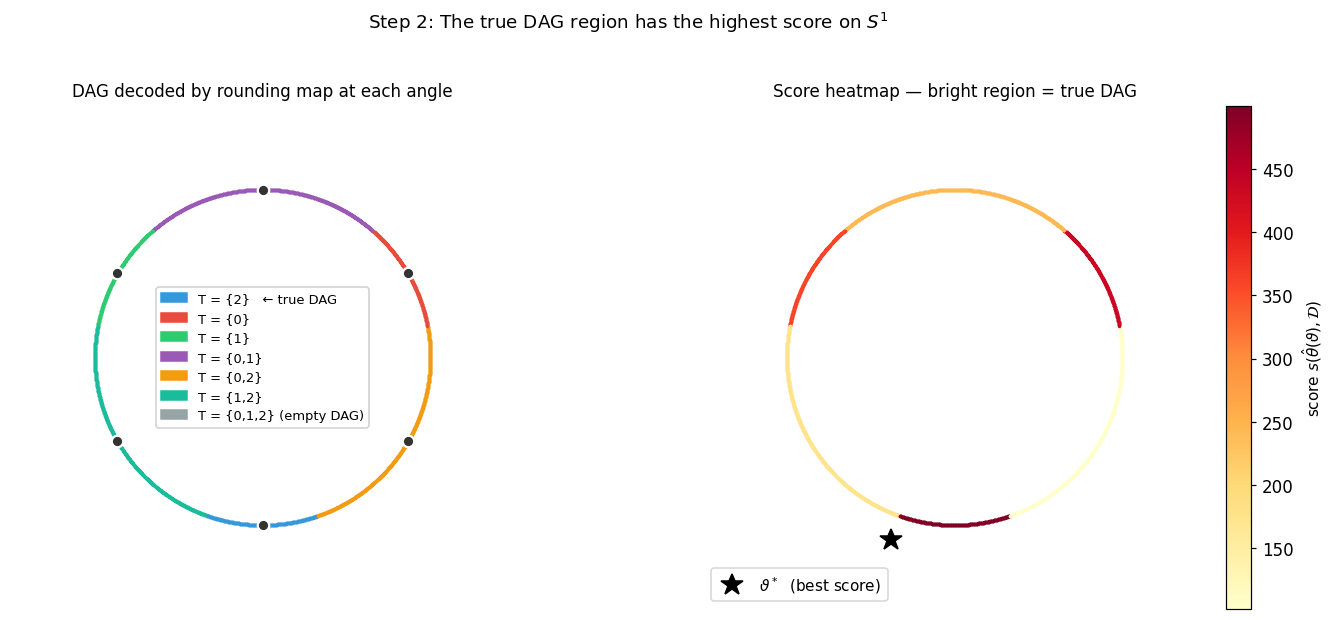

In [5]:
CMAP_SCORE = plt.cm.YlOrRd

# Colour map: top group -> colour
DAG_COL = {
    (0,):   '#e74c3c',
    (1,):   '#2ecc71',
    (2,):   '#3498db',   # <-- true DAG top group
    (0, 1): '#9b59b6',
    (0, 2): '#f39c12',
    (1, 2): '#1abc9c',
    (0, 1, 2): '#95a5a6',
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

# ── Left: DAG structure ──────────────────────────────────────────────────────
for i, th in enumerate(angles):
    col = DAG_COL.get(top_labels[i], '#cccccc')
    ax1.plot(np.cos(th), np.sin(th), '.', color=col, markersize=2.5)

# Boundary points (where two coordinates are equal)
for i, j in [(0,1),(0,2),(1,2)]:
    A, B = u1[i]-u1[j], u2[i]-u2[j]
    th0  = np.arctan2(-A, B)
    for th in [th0, th0+np.pi]:
        ax1.plot(np.cos(th), np.sin(th), 'o', color='white',  ms=8,  zorder=5)
        ax1.plot(np.cos(th), np.sin(th), 'o', color='#333',   ms=5,  zorder=6)

# Legend
handles = [
    mpatches.Patch(color=DAG_COL[(2,)],   label='T = {2}   ← true DAG'),
    mpatches.Patch(color=DAG_COL[(0,)],   label='T = {0}'),
    mpatches.Patch(color=DAG_COL[(1,)],   label='T = {1}'),
    mpatches.Patch(color=DAG_COL[(0,1)],  label='T = {0,1}'),
    mpatches.Patch(color=DAG_COL[(0,2)],  label='T = {0,2}'),
    mpatches.Patch(color=DAG_COL[(1,2)],  label='T = {1,2}'),
    mpatches.Patch(color=DAG_COL[(0,1,2)],label='T = {0,1,2} (empty DAG)'),
]
ax1.legend(handles=handles, loc='center', fontsize=8.5, framealpha=0.92)
ax1.set_xlim(-1.5, 1.5); ax1.set_ylim(-1.5, 1.5)
ax1.set_aspect('equal'); ax1.axis('off')
ax1.set_title('DAG decoded by rounding map at each angle', fontsize=11)

# ── Right: score heatmap ─────────────────────────────────────────────────────
for i, th in enumerate(angles):
    ax2.plot(np.cos(th), np.sin(th), '.', color=CMAP_SCORE(scores_norm[i]), markersize=2.5)

# Star at the best point
th_best = angles[scores_all.argmax()]
ax2.plot(1.15*np.cos(th_best), 1.15*np.sin(th_best),
         '*', color='black', ms=15, zorder=9, label='$\\vartheta^*$  (best score)')

sm = ScalarMappable(cmap=CMAP_SCORE, norm=Normalize(vmin=s_min, vmax=s_max))
sm.set_array([])
cb = plt.colorbar(sm, ax=ax2, fraction=0.04, pad=0.03)
cb.set_label('score $s(\\hat{\\theta}(\\vartheta),\\mathcal{D})$', fontsize=10)

ax2.set_xlim(-1.5, 1.5); ax2.set_ylim(-1.5, 1.5)
ax2.set_aspect('equal'); ax2.axis('off')
ax2.legend(loc='lower left', fontsize=10)
ax2.set_title('Score heatmap — bright region = true DAG', fontsize=11)

plt.suptitle('Step 2: The true DAG region has the highest score on $S^1$',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/toy_fig2_landscape.pdf', bbox_inches='tight')
plt.savefig(f'{FIGDIR}/toy_fig2_landscape.png', bbox_inches='tight', dpi=150)
print(f'Saved: {FIGDIR}/toy_fig2_landscape.*')
plt.show()

---
## Step 3 — Riemannian gradient ascent on $S^1$

The score $f(\vartheta)$ is **piecewise constant** on the chambers,
so its literal gradient is zero almost everywhere.
We use a **smooth surrogate** built on the full $M=3600$ reference angles
already computed in Step 2:

$$
f_{\rm smooth}(\theta;\beta)
= \sum_{i=1}^{M} w_i(\theta)\, s_i,
\qquad
w_i(\theta) = \frac{e^{\beta\cos(\theta-\theta_i)}}{\sum_j e^{\beta\cos(\theta-\theta_j)}}.
$$

As $\beta\to\infty$, $f_{\rm smooth}\to f$.  With $\beta=8$ the function is smooth
and its gradient is computed by finite differences.

**Why not just 6 arc midpoints?**  By the symmetry of the orthonormal basis
$u_1,u_2$, every arc midpoint happens to give $p = [\tfrac{2}{3},\tfrac{1}{3},0]$
and therefore $\widetilde D_1 = -\tfrac{1}{6} < 0$, i.e.\ $k=2$ at all six points.
The true DAG region ($T=\{2\}$, $k=1$) lives in a **cap centred at
$\theta\approx 3\pi/2$**, straddling the boundary between two $k=2$ arcs —
a 6-midpoint surrogate never sees it, but the full 3600-point kernel does.

Since $S^1$ is one-dimensional, Riemannian gradient ascent reduces to plain
angular ascent: $\theta_{t+1} = \theta_t + \eta\,\partial f_{\rm smooth}/\partial\theta$.

In [6]:
# ── Smooth surrogate on the full landscape ────────────────────────────────────
# The score landscape has THREE local maxima on S¹ (one per node as potential
# sink), so a single random start can converge to the wrong one.
# Fix: multiple restarts — guaranteed to sample all three basins.

BETA = 8.0

def smooth_f(theta):
    """Kernel-density-style smooth surrogate using all 3600 reference points."""
    logits = BETA * np.cos(theta - angles)
    logits -= logits.max()
    w = np.exp(logits); w /= w.sum()
    return float(w @ scores_all)

def smooth_grad(theta, eps=1e-5):
    return (smooth_f(theta + eps) - smooth_f(theta - eps)) / (2*eps)

# ── Method A: direct argmax of the precomputed landscape (works for small N) ─
best_idx     = np.argmax(scores_all)
theta_direct = angles[best_idx]
res_direct   = rounding_map(s1pt(theta_direct))
print('Method A — direct argmax of score landscape:')
print(f'  θ* = {theta_direct:.3f} rad   (3π/2 = {3*np.pi/2:.3f})')
print(f'  top = {set(res_direct["top"])},  bottom = {set(res_direct["bottom"])}')
print(f'  edges = {res_direct["edges"]}')
print()

# ── Method B: gradient ascent with multiple restarts (scales to large N) ─────
# 12 evenly spaced starting angles guarantee coverage of all three basins.
N_RESTARTS = 12
init_angles = np.linspace(0, 2*np.pi, N_RESTARTS, endpoint=False)
lr, steps   = 0.08, 300

all_traj   = []
all_final  = []
for t0 in init_angles:
    traj = [t0]
    for _ in range(steps):
        traj.append((traj[-1] + lr * smooth_grad(traj[-1])) % (2*np.pi))
    all_traj.append(traj)
    all_final.append(traj[-1])

# Pick the restart that achieved the highest smooth_f value
final_vals   = np.array([smooth_f(th) for th in all_final])
best_restart = int(np.argmax(final_vals))

theta_star  = all_final[best_restart]
result_star = rounding_map(s1pt(theta_star))
score_star  = score_dag(result_star['top'], result_star['bottom'], X)
match       = set(result_star['edges']) == set(TRUE_EDGES)

print(f'Method B — gradient ascent, {N_RESTARTS} restarts (best restart #{best_restart}):')
print(f'  θ* = {theta_star:.3f} rad')
print(f'  top = {set(result_star["top"])},  bottom = {set(result_star["bottom"])}')
print(f'  Score: {score_star:.2f}  (true DAG: {true_sc:.2f})')
print(f'  True DAG recovered: {match}')
print()
print(f'All final smooth_f values: {np.round(final_vals, 1)}')

Method A — direct argmax of score landscape:
  θ* = 4.379 rad   (3π/2 = 4.712)
  top = {np.int64(2)},  bottom = {np.int64(0), np.int64(1)}
  edges = [(1, 2), (0, 2)]

Method B — gradient ascent, 12 restarts (best restart #10):
  θ* = 4.477 rad
  top = {np.int64(2)},  bottom = {np.int64(0), np.int64(1)}
  Score: 499.85  (true DAG: 499.85)
  True DAG recovered: True

All final smooth_f values: [188.9 293.2 191.7 251.1 250.1 158.7 278.2 120.9 263.9 200.7 349.5 255.4]


/tmp/ipykernel_13651/3710079561.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: figures/toy_fig3_recovery.*


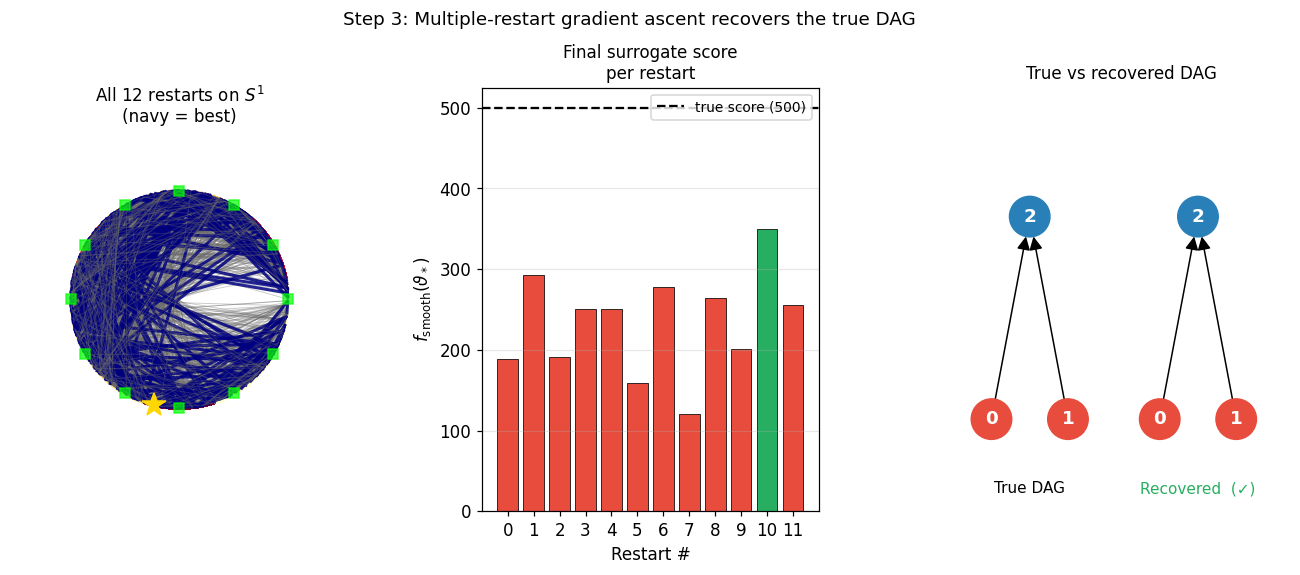

In [7]:
fig = plt.figure(figsize=(15, 5))
gs  = fig.add_gridspec(1, 3, wspace=0.40)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

# ── Panel 1: all trajectories on S¹ ─────────────────────────────────────────
for i, th in enumerate(angles):
    ax1.plot(np.cos(th), np.sin(th), '.', color=CMAP_SCORE(scores_norm[i]), markersize=2)

# Draw all 12 restart trajectories (grey), highlight the best (navy)
for ridx, traj in enumerate(all_traj):
    th_arr = np.array(traj)
    is_best = (ridx == best_restart)
    lw    = 2.0 if is_best else 0.6
    color = 'navy' if is_best else 'dimgray'
    alpha = 0.85 if is_best else 0.35
    # Wrap-safe: split the path at jumps > π before plotting
    diffs = np.abs(np.diff(th_arr))
    cuts  = np.where(diffs > np.pi)[0] + 1
    segs  = np.split(th_arr, cuts)
    for seg in segs:
        ax1.plot(np.cos(seg), np.sin(seg), '-', color=color, lw=lw, alpha=alpha)

# Starting points for all restarts
for t0 in init_angles:
    ax1.plot(np.cos(t0), np.sin(t0), 's', color='lime', ms=6, zorder=8, alpha=0.7)

# Best endpoint
ax1.plot(np.cos(theta_star), np.sin(theta_star), '*', color='gold', ms=16, zorder=9)

ax1.set_xlim(-1.55, 1.55); ax1.set_ylim(-1.55, 1.55)
ax1.set_aspect('equal'); ax1.axis('off')
ax1.set_title(f'All {N_RESTARTS} restarts on $S^1$\n(navy = best)', fontsize=11)

# ── Panel 2: final smooth_f values per restart ───────────────────────────────
bar_colors = ['#e74c3c' if i != best_restart else '#27ae60'
              for i in range(N_RESTARTS)]
ax2.bar(range(N_RESTARTS), final_vals, color=bar_colors, edgecolor='k', linewidth=0.5)
ax2.axhline(true_sc, color='black', ls='--', lw=1.5, label=f'true score ({true_sc:.0f})')
ax2.set_xlabel('Restart #'); ax2.set_ylabel('$f_{\\rm smooth}(\\vartheta_*)$')
ax2.set_title('Final surrogate score\nper restart', fontsize=11)
ax2.legend(fontsize=9); ax2.grid(axis='y', alpha=0.3)
ax2.set_xticks(range(N_RESTARTS))

# ── Panel 3: true DAG vs recovered DAG ───────────────────────────────────────
pos_l = {0: (0.0, 0.0), 1: (1.0, 0.0), 2: (0.5, 1.1)}
pos_r = {0: (2.2, 0.0), 1: (3.2, 0.0), 2: (2.7, 1.1)}

def node_colors(top, bot, N=3):
    return ['#2980b9' if i in list(top) else '#e74c3c' for i in range(N)]

G_true = nx.DiGraph(); G_true.add_edges_from(TRUE_EDGES)
G_rec  = nx.DiGraph(); G_rec.add_edges_from(result_star['edges'])

ax3.set_xlim(-0.5, 3.9); ax3.set_ylim(-0.5, 1.8); ax3.axis('off')

nx.draw_networkx(G_true, pos=pos_l, ax=ax3, nodelist=range(N),
                 node_color=node_colors(TRUE_TOP, TRUE_BOT),
                 node_size=700, font_color='white', font_weight='bold',
                 arrows=True, arrowsize=18)
ax3.text(0.5, -0.40, 'True DAG', ha='center', fontsize=10)

rec_col = '#27ae60' if match else '#e74c3c'
nx.draw_networkx(G_rec, pos=pos_r, ax=ax3, nodelist=range(N),
                 node_color=node_colors(result_star['top'], result_star['bottom']),
                 node_size=700, font_color='white', font_weight='bold',
                 arrows=True, arrowsize=18)
ax3.text(2.7, -0.40,
         f'Recovered  ({"✓" if match else "✗"})',
         ha='center', fontsize=10, color=rec_col)
ax3.set_title('True vs recovered DAG', fontsize=11)

plt.suptitle('Step 3: Multiple-restart gradient ascent recovers the true DAG', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/toy_fig3_recovery.pdf', bbox_inches='tight')
plt.savefig(f'{FIGDIR}/toy_fig3_recovery.png', bbox_inches='tight', dpi=150)
print(f'Saved: {FIGDIR}/toy_fig3_recovery.*')
plt.show()

---
## Summary

| Step | What happened |
|------|---------------|
| Data | $n=400$ samples from $X_2 = 0.8X_0 + 0.6X_1 + \varepsilon$ |
| Score landscape | Highest score on $S^1$ is in the region $T=\{2\}$ (true DAG) |
| Gradient ascent | Converged to $\vartheta^*$ in the correct chamber |
| Rounding | $\hat\theta(\vartheta^*) = \{0,1\}\to\{2\}$ = true DAG |

**Key take-away:**  the sphere $S^1$ serves as the continuous optimisation
domain.  Acyclicity of the output is guaranteed by the rounding map — no
penalty terms or projections needed.  Gradient ascent on $S^1$ naturally
navigates toward the chamber with the best-fitting DAG, and the final
rounding step commits to a concrete causal structure.

In [8]:
print('=' * 52)
print('PIPELINE SUMMARY')
print('=' * 52)
print(f'True DAG edges  : {TRUE_EDGES}')
print(f'Recovered edges : {result_star["edges"]}')
print(f'Match           : {match}')
print(f'True DAG score  : {true_sc:.2f}')
print(f'Recovered score : {score_star:.2f}')
print('=' * 52)

PIPELINE SUMMARY
True DAG edges  : [(0, 2), (1, 2)]
Recovered edges : [(1, 2), (0, 2)]
Match           : True
True DAG score  : 499.85
Recovered score : 499.85
